In [2]:
library(tidyverse)
library(dbplyr)
library(bigrquery)
library(lubridate)

bq_auth()

project_id = "yhcr-prd-bradfor-bia-core"

# create connection to database
con <- DBI::dbConnect(bigrquery::bigquery(), 
                      project = project_id)

print(paste0("Connected to : ", project_id))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




[1] "Connected to : yhcr-prd-bradfor-bia-core"


# Absence

In [3]:
person_ids <- read.csv('data/person_ids.csv', header = TRUE)

In [5]:
absence_data = "CB_2489.cb_Absence"

absence_table <- tbl(con, absence_data) |>
    select(person_id, sourcetable,AcademicYear, Term, SessionsPossible, AuthorisedAbsence, UnauthorisedAbsence, OverallAbsence) 
    # convert to df
    #collect()


In [6]:
head(absence_table)

# Source:   SQL [6 x 8]
# Database: BigQueryConnection
  person_id    sourcetable AcademicYear Term  SessionsPossible AuthorisedAbsence
  <chr>        <chr>       <chr>        <chr>            <dbl>             <dbl>
1 52F91FA12EF… NA          2005/2006    3Term              310                 0
2 B95634797D4… NA          2005/2006    3Term              306                 2
3 478E8E6D679… NA          2005/2006    3Term              307                31
4 A71419D65AF… NA          2005/2006    3Term              308                13
5 A88EEE1F277… NA          2005/2006    3Term              242                45
6 432D3F547DB… NA          2005/2006    3Term              300                28
# ℹ 2 more variables: UnauthorisedAbsence <dbl>, OverallAbsence <dbl>

In [7]:
absence_df <- collect(absence_table)

In [8]:
unique(absence_df$sourcetable)

[1] NA

In [9]:
absence_df <- absence_df |> select(-sourcetable)

In [10]:
unique(absence_df$Term)

[1] "5HalfTerms" "6HalfTerms" "Spring"     "Autumn"     "Summer6th" 
 [6] "3Term"      "6HalfTerm"  "1Term"      "Annual"     "Summer"

In [11]:
unique(absence_df$AcademicYear)

[1] "2015/2016" "2016/2017" "2017/2018" "2018/2019" "2020/2021" "2009/2010"
 [7] "2011/2012" "2012/2013" "2013/2014" "2014/2015" "2019/2020" "2008/2009"
[13] "2010/2011" "2007/2008" "2005/2006" "2006/2007"

In [12]:
absence_df |>
    filter(AcademicYear == '2015/2016') |>
    filter(!Term %in% c('5HalfTerms','Autumn','Spring','Summer','1Term','Summer6th'))

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
DF788D7F70329F2C1211FBF0AF8F85852F4E26AF6D95741515608CBD300468FC,2015/2016,Annual,314,166,0,166
9F8BD31C773EA7FF03431BE46E08CB96408EECF6E96F809D0BB80907116934DA,2015/2016,Annual,312,300,0,300
7415049501B7004879D553A4FB05FB3087F0B40CF52C408EC9952CDB28CE6E6D,2015/2016,Annual,310,58,0,58
9DB3130F27EB36644095B0CC57B0F0FC6635FF24EC6D2539C958BA8BFCF6CEAF,2015/2016,Annual,306,33,28,61
E0EBA5CC91B686780BBD079190A30E15A997DEA48DEB5E731DAED556B9C53A7B,2015/2016,Annual,310,118,5,123
E8035EC933245E4644D23257A050A16862ACE799D1AE067368F84594DD236AD0,2015/2016,Annual,310,31,0,31
B0E07D6AF85B60C91FCB58DF32A769121FB9D59C44943810D215B6FE586667EF,2015/2016,Annual,314,34,1,35
4B54B24661A52410CDEF1628264A5F1E3D022B0F2B7F323F2A97AA4046AA4D1B,2015/2016,Annual,310,26,1,27
D8F4DFC3E1CEC6564D51F81B01268BBF9FA35CF326A4B8C0A3D454BFF0286A69,2015/2016,Annual,316,227,3,230


In [13]:
absence_df |>
    filter(person_id == '004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894') |>
    arrange(AcademicYear)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2006/2007,Autumn,140,1,4,5
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2006/2007,Spring,114,0,0,0
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2006/2007,Summer,58,0,0,0
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2006/2007,3Term,312,1,4,5
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2007/2008,3Term,310,2,2,4
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2007/2008,Spring,96,0,2,2
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2007/2008,Autumn,146,0,0,0
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2007/2008,Summer,68,2,0,2
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2008/2009,Spring,116,2,0,2


In [14]:
absence_years <- absence_df |>
    filter(AcademicYear %in% c('2012/2013','2013/2014','2014/2015','2015/2016','2016/2017','2017/2018')) 
    #filter(Term %in% c('6HalfTerm', '6HalfTerms', 'Annual'))

In [15]:
absence_years |>
    filter(person_id == '00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29') |>
    filter(AcademicYear == '2015/2016')

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2015/2016,Summer6th,70,12,2,14
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2015/2016,5HalfTerms,306,14,4,18
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2015/2016,Summer,68,2,0,2
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2015/2016,Spring,106,8,0,8
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2015/2016,Autumn,132,4,4,8


In [16]:
absence_years |>
    filter(person_id == '0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD') |>
    filter(AcademicYear == '2015/2016')

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2015/2016,Spring,106,2,0,2
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2015/2016,Autumn,134,8,2,10
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2015/2016,5HalfTerms,240,10,2,12


In [17]:
absence_years |>
    filter(AcademicYear == '2015/2016')

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
DB46ECDD62FCAF376BFA2AAF2FD077A344277A31E6AAF98456DB181347CD6671,2015/2016,5HalfTerms,314,25,6,31
0CBADEB47181F1F91E48610DC6A1E7EF8ECD8572BD426F0A9EFA1D77197B3604,2015/2016,5HalfTerms,316,16,21,37
AABD2391E6CA4FF98E8ACE251136892C53D059461686D655FAFD68DC90EF68D4,2015/2016,5HalfTerms,309,6,30,36
9AECBED3F9FC2EA9645EF4997575A1B7B4082F3556212626799653F537B3B150,2015/2016,5HalfTerms,318,22,10,32
15E284BE438308D594CACF5E12ECE2F5052792186101752D9BC39B7E11738DFD,2015/2016,5HalfTerms,71,28,31,59
DF788D7F70329F2C1211FBF0AF8F85852F4E26AF6D95741515608CBD300468FC,2015/2016,Annual,314,166,0,166
6C0DE00568E675396C1BC155FA4B94702B76AF2D75E156FF7736B4CFD0F956E6,2015/2016,5HalfTerms,273,12,76,88
66BF97DD779B0D28B3C635443B0E55CF256E6EF4452BD153BEC0FEA48FEAC721,2015/2016,5HalfTerms,314,8,134,142
5545A7DC5B2738B29D8B3237B6141C5E54F6CA19C7104FE655CB1DD8043428B1,2015/2016,5HalfTerms,312,17,47,64


In [18]:
absence_years <- absence_years |>
    mutate(Term = case_when(
            Term == '6HalfTerm' ~ '6HalfTerms',
            TRUE ~ Term)
           )

## filter by person id per cohort to get correct years

In [19]:
head(person_ids)

,person_id,NCCIS_ACADYR
,<chr>,<chr>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018


In [20]:
ids_cohort1 <- person_ids |>
    filter(NCCIS_ACADYR == '2017/2018')

In [21]:
ids_cohort2 <- person_ids |>
    filter(NCCIS_ACADYR == '2018/2019')

Check for matching IDs across 2 cohorts (as end up with duplicates for some rows later)

In [88]:
any(ids_cohort1$person_id %in% ids_cohort2$person_id)

[1] FALSE

In [89]:
any(ids_cohort2$person_id %in% ids_cohort1$person_id)

[1] FALSE

In [22]:
absence_cohort1 <- absence_years |>
    filter(person_id %in% ids_cohort1$person_id)

In [23]:
head(absence_cohort1)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
95F8C57869682FC037980AA73B22119A577603C8B7EEDB7850A33A3C072D73B4,2012/2013,6HalfTerms,368,38,0,38
76EFC332D3BB51923BEAFDD977A3F89DB741C9F9C834AA2AF961A66F4F40279C,2012/2013,5HalfTerms,294,30,36,66
78C8A468510F282F3AFD4B0B62C1A8590185E196FB9C2E07293A3ABA37490F12,2013/2014,6HalfTerms,196,59,68,127
3BCA9397B0ED70DB6361562793B6AF1D927FF920B6D800CE786A24BBD53E2582,2013/2014,6HalfTerms,372,65,0,65
15E284BE438308D594CACF5E12ECE2F5052792186101752D9BC39B7E11738DFD,2015/2016,5HalfTerms,71,28,31,59
FE47AC5ADFDA6F21251363CDE72F3C1305D84EF33FDB0814F25C82B9FAFA64A6,2015/2016,5HalfTerms,310,20,26,46


In [24]:
absence_cohort2 <- absence_years |>
    filter(person_id %in% ids_cohort2$person_id)

In [25]:
ids_cohort1 |> nrow()

[1] 8686

In [26]:
absence_cohort1 |> nrow()

[1] 219718

In [27]:
absence_cohort1 |> summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
8464


In [28]:
ids_cohort2 |> nrow()

[1] 8675

In [29]:
absence_cohort2 |> nrow()

[1] 279238

In [30]:
absence_cohort2 |> summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
8559


In [31]:
head(absence_cohort2)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
29D8C59366DEB6718492AC773027C666C5A40A161508162BFD968B66A4609E33,2016/2017,5HalfTerms,308,41,36,77
377391278D02F08C4193B38D69080E58853357B5DF3D37126418FC9EA1C65064,2017/2018,6HalfTerms,308,23,16,39
2273607AF282238837AA006E89B719DBADA92FA25B70F94C594F33E02976A9DD,2012/2013,Spring,104,29,5,34
BAA892C9910DC819B84E2B110B932D7A05F1143BBBD18CB8D7FC29949D9E9F3E,2014/2015,6HalfTerms,376,44,12,56
1A361EC49113751D374BAE7A31B9DEFC1B4CF1589163844883B464A891CBF218,2017/2018,6HalfTerms,302,24,30,54
9CCE0F94BC689EA60C1C28522DAC4884BACB8B97E665DAE84C4D0767B6F16561,2014/2015,6HalfTerms,378,9,26,35


In [32]:
absence_cohort1 <- absence_cohort1 |>
    filter(AcademicYear %in% c('2012/2013','2013/2014','2014/2015','2015/2016','2016/2017'))

In [33]:
absence_cohort2 <- absence_cohort2 |>
    filter(AcademicYear %in% c('2013/2014','2014/2015','2015/2016','2016/2017','2017/2018'))

In [191]:
absence_joined <- rbind(absence_cohort1, absence_cohort2)

In [192]:
absence_joined <- absence_joined |> distinct()

In [193]:
absence_joined |> nrow()

[1] 450069

check where there are two rows with the same person, year, term and sessions possible, and keep higher overall absence as when manually checking the higher overall absence matches the totals for the smaller time increments. 

In [194]:
absence_joined <- absence_joined |> 
    group_by(person_id, AcademicYear, Term, SessionsPossible) |> 
    mutate(duplicate_flag = n() > 1) |>  # Identify groups with more than one row
    filter(!duplicate_flag | OverallAbsence == max(OverallAbsence)) |>  # Keep max OverallAbsence where needed
    ungroup() |> 
    select(-duplicate_flag) |>  # Remove helper column
    arrange(person_id, AcademicYear, Term)

In [195]:
absence_joined |> nrow()

[1] 449966

In [196]:
# this one doesnt matter because not using 5terms for 13/14
absence_joined |> 
    group_by(person_id, AcademicYear, Term, SessionsPossible) |>
    filter(n() > 1) |>
    ungroup() |>
    arrange(person_id, AcademicYear, Term)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2013/2014,5HalfTerms,138,10,2,12
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2013/2014,5HalfTerms,138,12,0,12


## calculate absence rates

In [197]:
unique(absence_joined$Term)

[1] "5HalfTerms" "6HalfTerms" "Autumn"     "Spring"     "Summer"    
[6] "Summer6th"  "Annual"

In [198]:
term_checker <- absence_joined %>%
  group_by(person_id, AcademicYear) %>%
  summarise(
      has_6halfterms = any(Term == "6HalfTerms"),
      has_annual = any(Term == "Annual"),
      has_5plus6 = all(c("5HalfTerms", "Summer6th") %in% Term),
      has_3term = all(c("Autumn", "Spring", "Summer") %in% Term),
      has_5halfterms = any(Term == "5HalfTerms"),
      .groups = "drop")

In [199]:
# check for any left out
term_checker |>
    filter(!has_6halfterms & !has_annual & !has_5plus6 & !has_3term & !has_5halfterms) 

person_id,AcademicYear,has_6halfterms,has_annual,has_5plus6,has_3term,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>


#### 6 half terms

In [200]:
term_check_6half <- term_checker |>
    filter(has_6halfterms)

In [201]:
term_check_6half |> nrow()

[1] 65678

In [202]:
absence_6half <- absence_joined |>
    filter(person_id %in% term_check_6half$person_id) |>
    filter(Term == '6HalfTerms') |>
    distinct()

In [203]:
absence_6half |> nrow()

[1] 67822

In [204]:
absence_6half |>
    filter(person_id == '062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724')

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724,2013/2014,6HalfTerms,378,24,0,24
062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724,2014/2015,6HalfTerms,378,35,0,35
062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724,2016/2017,6HalfTerms,380,0,0,0
062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724,2016/2017,6HalfTerms,268,26,13,39
062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724,2017/2018,6HalfTerms,298,0,0,0
062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724,2017/2018,6HalfTerms,296,9,1,10


In [205]:
absence_6half |>
  group_by(person_id, AcademicYear) |>
  filter(n() > 1) |>
  ungroup() |>
    arrange(person_id)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2013/2014,6HalfTerms,262,24,15,39
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2013/2014,6HalfTerms,92,0,0,0
0054192801954D860BB235F844AD1CB8A99956B2CF3D4E20F83C650DD6279B58,2012/2013,6HalfTerms,41,0,1,1
0054192801954D860BB235F844AD1CB8A99956B2CF3D4E20F83C650DD6279B58,2012/2013,6HalfTerms,329,3,6,9
0069000F2F3F16C7687450D2AE517987DAFB0E7BAF4C2F19AF109466BC5377D8,2016/2017,6HalfTerms,26,3,1,4
0069000F2F3F16C7687450D2AE517987DAFB0E7BAF4C2F19AF109466BC5377D8,2016/2017,6HalfTerms,346,0,26,26
00A0BB9E50F2E2C8181D0DACFEFF0F3136172F3133377432BB753099B678A32D,2013/2014,6HalfTerms,4,0,0,0
00A0BB9E50F2E2C8181D0DACFEFF0F3136172F3133377432BB753099B678A32D,2013/2014,6HalfTerms,420,15,6,21
00A6CFE5C25E69EC51F67C74E4F40F8AECFE43014AD77CBCB2ADA9ECBBB96BA6,2017/2018,6HalfTerms,12,7,2,9


In [206]:
absence_6half <- absence_6half |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [207]:
absence_6half |> nrow()

[1] 65678

#### Annual

In [208]:
term_check_annual <- term_checker |>
    filter(!has_6halfterms & has_annual)

In [209]:
term_check_annual |> nrow()

[1] 212

In [210]:
head(term_check_annual)

person_id,AcademicYear,has_6halfterms,has_annual,has_5plus6,has_3term,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
04266F70EC53F4D0BBD5349523CF9F1C0FC46E088E0BF75782BECAA0B03E7225,2015/2016,FALSE,TRUE,TRUE,FALSE,TRUE
04C8C526DF6BB045C0666CEDDDA084C950F8BC8CE41BC28EC08A0A998368EE83,2015/2016,FALSE,TRUE,TRUE,FALSE,TRUE
05A46A79FC048B6ADE61F2AC05EA70561C8DFDAA836AF7176963B181E4775598,2015/2016,FALSE,TRUE,TRUE,FALSE,TRUE
08FD9831432E0BCF8BA1E3EEB051E6BF00D84BF6AD0DD51CFA8B0F0AD4B0C413,2015/2016,FALSE,TRUE,TRUE,FALSE,TRUE
09477139A7592F99DEC0FAAA0D660476EDD5761FC51412CC4BCE350DD2DBE3F2,2015/2016,FALSE,TRUE,TRUE,FALSE,TRUE
13ECC6DF4CDBF4C36F97D4FC9C14B222B0F77C74357D76D0684D7C26EBF6624D,2015/2016,FALSE,TRUE,FALSE,FALSE,TRUE


In [211]:
absence_annual <- absence_joined |>
    filter(person_id %in% term_check_annual$person_id & AcademicYear %in% term_check_annual$AcademicYear) |>
    filter(Term == 'Annual') |>
    distinct() |>
    select(-Term)

In [212]:
absence_annual |> nrow()

[1] 212

#### 5 plus 6

In [213]:
term_check_5plus6 <- term_checker |>
    filter(!has_6halfterms & !has_annual & has_5plus6)

In [214]:
term_check_5plus6 |> nrow()

[1] 14453

In [215]:
head(term_check_5plus6)

person_id,AcademicYear,has_6halfterms,has_annual,has_5plus6,has_3term,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,2015/2016,FALSE,FALSE,TRUE,TRUE,TRUE


In [216]:
absence_5plus6 <- absence_joined |>
    filter(person_id %in% term_check_5plus6$person_id & AcademicYear %in% term_check_5plus6$AcademicYear) |>
    filter(Term %in% c("5HalfTerms", "Summer6th")) |>
    distinct()

In [217]:
absence_5plus6 |> nrow()

[1] 29840

In [218]:
absence_5plus6 <- absence_5plus6 |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [219]:
absence_5plus6 |> nrow()

[1] 14453

#### 3 Term

In [220]:
term_check_3term <- term_checker |>
    filter(!has_6halfterms & !has_annual & !has_5plus6 & has_3term)

In [221]:
term_check_3term |> nrow()

[1] 65

In [222]:
head(term_check_3term)

person_id,AcademicYear,has_6halfterms,has_annual,has_5plus6,has_3term,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0558143D7871BA70A789D99B69FFE1F3F793AC8D59A48E31DB7933D84F870536,2015/2016,FALSE,FALSE,FALSE,TRUE,TRUE
05D7F2723D01B95B59DEB210822A56A43E2D6225A998496B5595628422D79987,2015/2016,FALSE,FALSE,FALSE,TRUE,TRUE
08A3074E3ED2BF5BF7B31BB0DF4A1B727D6D17CE6E49A207D011E752186A6833,2015/2016,FALSE,FALSE,FALSE,TRUE,TRUE
11055AC07BB05C43583FB6BB0741F74F81524687D228D8A782D3BA9B667CCB4D,2015/2016,FALSE,FALSE,FALSE,TRUE,TRUE
14FF3F1FEF0B079FE0708137F7C973A4169F3312C4C2924EA9801EB736BF2F8F,2015/2016,FALSE,FALSE,FALSE,TRUE,TRUE
1980231E865CF35DF7E4BE0DA2A1AF3F521F29AD96777491A90788A72A174DDD,2015/2016,FALSE,FALSE,FALSE,TRUE,TRUE


In [223]:
absence_3term <- absence_joined |>
    filter(person_id %in% term_check_3term$person_id & AcademicYear %in% term_check_3term$AcademicYear) |>
    filter(Term %in% c("Autumn", "Spring", "Summer")) |>
    distinct()

In [224]:
absence_3term |> nrow()

[1] 214

In [225]:
absence_3term <- absence_3term |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [226]:
absence_3term |> nrow()

[1] 65

#### 5 half terms

In [227]:
term_check_5half <- term_checker |>
    filter(!has_6halfterms & !has_annual & !has_5plus6 & !has_3term & has_5halfterms)

In [228]:
term_check_5half |> nrow()

[1] 1861

2015/16 academic year is 5 halfterms of absences only

In [229]:
head(term_check_5half)

person_id,AcademicYear,has_6halfterms,has_annual,has_5plus6,has_3term,has_5halfterms
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE
00222373A6082CDBF94DA04F23E7EB4C8775BEE122FE9C29FBF521900A498EDF,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE
002EF3F17C7981C3D6FD842C559E9AA0626E06B3940B670DDA2B71F7070ADF7D,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE
003132A725233755576CF96E5AA2B3DF606A618754D4BDDFCDD5483849E7B946,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE
00341B29C42EC823E9D06B625E751614D66794F1096E2F045DDE51DB64C9C623,2015/2016,FALSE,FALSE,FALSE,FALSE,TRUE


In [230]:
absence_5half <- absence_joined |>
    filter(person_id %in% term_check_5half$person_id & AcademicYear %in% term_check_5half$AcademicYear) |>
    filter(Term == '5HalfTerms') |>
    distinct()

In [231]:
absence_5half |> nrow()

[1] 1920

In [232]:
absence_5half |>
  group_by(person_id, AcademicYear) |>
  filter(n() > 1) |>
  ungroup() |>
    arrange(person_id)

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0239CB13E86E69A92111DA56243394D513190F44FCA0BC9F32EDB644681F206E,2015/2016,5HalfTerms,160,0,4,4
0239CB13E86E69A92111DA56243394D513190F44FCA0BC9F32EDB644681F206E,2015/2016,5HalfTerms,82,0,2,2
0A3A177F604D4D6CE3EBED88C83E4C095E8F6EE6A039C564270D3FEE1F0BF990,2015/2016,5HalfTerms,239,13,3,16
0A3A177F604D4D6CE3EBED88C83E4C095E8F6EE6A039C564270D3FEE1F0BF990,2015/2016,5HalfTerms,1,0,0,0
1E954523D6B41852D78018F85A042C43B6323DC49784276D3B38FD947DAAA8BC,2015/2016,5HalfTerms,51,17,0,17
1E954523D6B41852D78018F85A042C43B6323DC49784276D3B38FD947DAAA8BC,2015/2016,5HalfTerms,50,4,0,4
1E954523D6B41852D78018F85A042C43B6323DC49784276D3B38FD947DAAA8BC,2015/2016,5HalfTerms,96,5,0,5
2FBD149B8AB3AF4FDD0BB0CFE80E6A86855003B8AAADC3BA21FFE29124659A56,2015/2016,5HalfTerms,234,12,6,18
2FBD149B8AB3AF4FDD0BB0CFE80E6A86855003B8AAADC3BA21FFE29124659A56,2015/2016,5HalfTerms,12,0,0,0


In [233]:
absence_5half <- absence_5half |>
    group_by(person_id, AcademicYear) |>
    summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
        )


In [234]:
absence_5half |> nrow()

[1] 1861

#### Re-join

In [235]:
summary(absence_6half)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:65678       Length:65678       Min.   :  1.0    Min.   :  0.0    
 Class :character   Class :character   1st Qu.:308.0    1st Qu.:  4.0    
 Mode  :character   Mode  :character   Median :374.0    Median :  9.0    
                                       Mean   :347.3    Mean   : 13.4    
                                       3rd Qu.:376.0    3rd Qu.: 18.0    
                                       Max.   :748.0    Max.   :327.0    
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.00      Min.   :  0.00  
 1st Qu.:  0.00      1st Qu.:  5.00  
 Median :  0.00      Median : 13.00  
 Mean   :  7.58      Mean   : 20.98  
 3rd Qu.:  6.00      3rd Qu.: 26.00  
 Max.   :377.00      Max.   :377.00  

In [239]:
absence_joined |> 
    filter(person_id == '8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069') |>
    filter(AcademicYear == '2014/2015')

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,5HalfTerms,295,42,0,42
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,5HalfTerms,311,11,2,13
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,6HalfTerms,369,44,0,44
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,6HalfTerms,379,11,2,13
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,Annual,295,42,0,42
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,Autumn,0,0,0,0
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,Spring,107,2,0,2
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,Summer,58,8,0,8
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,Summer6th,74,2,0,2


In [237]:
absence_6half |>
    filter(SessionsPossible > 400) |>
    arrange(desc(SessionsPossible)) |>
    summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
357


In [238]:
absence_6half |>
    filter(SessionsPossible > 400) |>
    arrange(desc(SessionsPossible)) 

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
8FC341376FC53A959C24D32BD3158846CC4CBA3E3AD931A9A0CB3644926A0069,2014/2015,748,55,2,57
6D20C690080F603371DFB752C207EE28C384B7CDF5643D12676B788B4FA13F8F,2014/2015,672,12,15,27
062B6966F4F02458747E850AF13D366D91B12411071AE55F23936F4C14136724,2016/2017,648,26,13,39
797D56A0F05B81F92E5F9EF94616CC48ED06ED0BE8DD4545E77824E8BD30FE8B,2014/2015,616,71,18,89
7C71CBD2AE820A8FB9E24F6E018AC3245582FBD400E9B27B4387A67BF9CBFCA0,2017/2018,608,20,0,20
F65B08C0ABA0DF84D9BD65F7FED88E1D5DAD42AAB47392CE2D9543AED4E245DD,2017/2018,604,47,51,98
3EF0D0F29242A1B2528C6CD7C26FA0BE326595D63C269C607EB8264D0C3EFBBA,2014/2015,600,50,102,152
E452D03EE60FE1BF1874A43FBDDAE2FB271ADEB500302A62C8987EC2A93383DA,2017/2018,599,12,8,20
5C4341701F0573FB1CAA44BB7FA5ADC9554337B8821CC317E6C008FB14D27522,2017/2018,596,32,40,72


In [141]:
summary(absence_annual)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:212         Length:212         Min.   : 13.0    Min.   :  0.00   
 Class :character   Class :character   1st Qu.:306.0    1st Qu.:  4.00   
 Mode  :character   Mode  :character   Median :310.0    Median : 14.00   
                                       Mean   :296.6    Mean   : 25.93   
                                       3rd Qu.:314.0    3rd Qu.: 29.25   
                                       Max.   :320.0    Max.   :300.00   
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.000     Min.   :  0.00  
 1st Qu.:  0.000     1st Qu.:  6.00  
 Median :  0.000     Median : 18.00  
 Mean   :  8.311     Mean   : 34.24  
 3rd Qu.:  3.000     3rd Qu.: 37.25  
 Max.   :310.000     Max.   :310.00  

In [142]:
summary(absence_5plus6)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:14453       Length:14453       Min.   : 66.0    Min.   :  0.00   
 Class :character   Class :character   1st Qu.:374.0    1st Qu.:  4.00   
 Mode  :character   Mode  :character   Median :376.0    Median : 10.00   
                                       Mean   :370.4    Mean   : 14.55   
                                       3rd Qu.:378.0    3rd Qu.: 19.00   
                                       Max.   :676.0    Max.   :352.00   
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.000     Min.   :  0.00  
 1st Qu.:  0.000     1st Qu.:  7.00  
 Median :  2.000     Median : 15.00  
 Mean   :  9.208     Mean   : 23.75  
 3rd Qu.:  8.000     3rd Qu.: 28.00  
 Max.   :376.000     Max.   :376.00  

In [143]:
summary(absence_3term)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:65          Length:65          Min.   :116.0    Min.   :  0.00   
 Class :character   Class :character   1st Qu.:249.0    1st Qu.:  6.00   
 Mode  :character   Mode  :character   Median :282.0    Median : 17.00   
                                       Mean   :268.6    Mean   : 22.88   
                                       3rd Qu.:300.0    3rd Qu.: 29.00   
                                       Max.   :348.0    Max.   :133.00   
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.0       Min.   :  0.00  
 1st Qu.:  4.0       1st Qu.: 27.00  
 Median : 16.0       Median : 38.00  
 Mean   : 40.2       Mean   : 63.08  
 3rd Qu.: 47.0       3rd Qu.: 78.00  
 Max.   :208.0       Max.   :232.00  

In [144]:
summary(absence_5half)

  person_id         AcademicYear       SessionsPossible AuthorisedAbsence
 Length:1861        Length:1861        Min.   :  1.0    Min.   :  0.000  
 Class :character   Class :character   1st Qu.:239.0    1st Qu.:  2.000  
 Mode  :character   Mode  :character   Median :240.0    Median :  6.000  
                                       Mean   :232.2    Mean   :  8.833  
                                       3rd Qu.:240.0    3rd Qu.: 12.000  
                                       Max.   :432.0    Max.   :116.000  
 UnauthorisedAbsence OverallAbsence  
 Min.   :  0.000     Min.   :  0.00  
 1st Qu.:  0.000     1st Qu.:  4.00  
 Median :  0.000     Median : 10.00  
 Mean   :  6.744     Mean   : 15.58  
 3rd Qu.:  5.000     3rd Qu.: 20.00  
 Max.   :215.000     Max.   :215.00  

In [240]:
absence_final <- rbind(absence_6half, absence_annual, absence_5plus6, absence_3term, absence_5half)

In [890]:
head(absence_final)

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2012/2013,374,2,0,2
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2013/2014,374,6,0,6
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2014/2015,375,26,0,26
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2016/2017,274,0,0,0
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2012/2013,374,21,0,21
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2013/2014,268,12,2,14


In [241]:
absence_final |>
    filter(person_id == 'B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC')

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2012/2013,373,21,7,28
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2013/2014,372,22,26,48
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2014/2015,370,60,56,116
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2016/2017,304,27,119,146
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2015/2016,116,0,0,0


In [243]:
absence_joined |>
    filter(person_id == 'B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC')|>
    filter(AcademicYear == '2015/2016')

person_id,AcademicYear,Term,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2015/2016,5HalfTerms,116,0,0,0
B518693FA5AD8C8DA6F39FBFCE85E1AF80A05EE2568C8158135115DB163B1EDC,2015/2016,Autumn,116,0,0,0


### save as csv

In [250]:
# save as csv
write.csv(absence_final, "data/absence_final.csv", row.names = FALSE)

## Calculate yearly rates

In [247]:
absence_rates <- absence_final |>
    mutate(
        AuthorisedAbsenceRate = (AuthorisedAbsence / SessionsPossible)*100,
        UnauthorisedAbsenceRate = (UnauthorisedAbsence / SessionsPossible)*100,
        TotalAbsenceRate = (OverallAbsence / SessionsPossible)*100
    ) |>
    select(-c(SessionsPossible, AuthorisedAbsence, UnauthorisedAbsence, OverallAbsence))

In [248]:
absence_rates

person_id,AcademicYear,AuthorisedAbsenceRate,UnauthorisedAbsenceRate,TotalAbsenceRate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2012/2013,0.5347594,0.0000000,0.5347594
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2013/2014,1.6042781,0.0000000,1.6042781
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2014/2015,6.9333333,0.0000000,6.9333333
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2016/2017,0.0000000,0.0000000,0.0000000
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2012/2013,5.6149733,0.0000000,5.6149733
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2013/2014,4.4776119,0.7462687,5.2238806
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2014/2015,1.0752688,4.8387097,5.9139785
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2016/2017,100.0000000,0.0000000,100.0000000
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2013/2014,0.5263158,0.0000000,0.5263158


### save as csv

In [251]:
# save as csv
write.csv(absence_rates, "data/absence_rates.csv", row.names = FALSE)

## Explore absences

In [252]:
summary(absence_rates)

  person_id         AcademicYear       AuthorisedAbsenceRate
 Length:82269       Length:82269       Min.   :  0.000      
 Class :character   Class :character   1st Qu.:  1.064      
 Mode  :character   Mode  :character   Median :  2.660      
                                       Mean   :  3.960      
                                       3rd Qu.:  5.236      
                                       Max.   :100.000      
 UnauthorisedAbsenceRate TotalAbsenceRate 
 Min.   :  0.0000        Min.   :  0.000  
 1st Qu.:  0.0000        1st Qu.:  1.596  
 Median :  0.2646        Median :  3.743  
 Mean   :  2.4583        Mean   :  6.419  
 3rd Qu.:  1.8717        3rd Qu.:  7.500  
 Max.   :100.0000        Max.   :100.000  

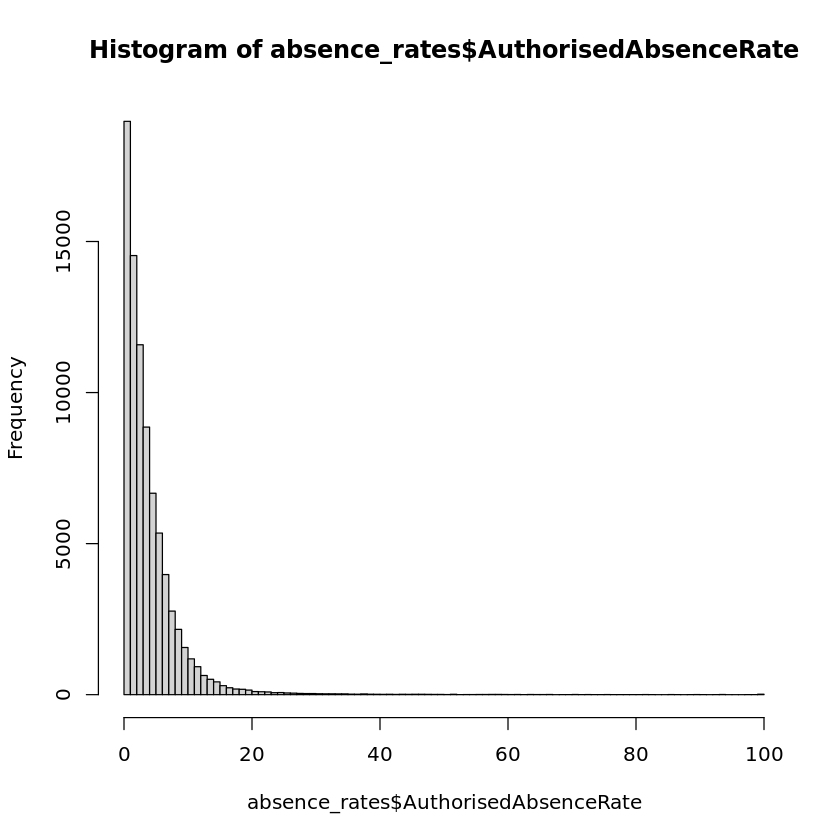

In [257]:
hist(absence_rates$AuthorisedAbsenceRate, breaks = 100)

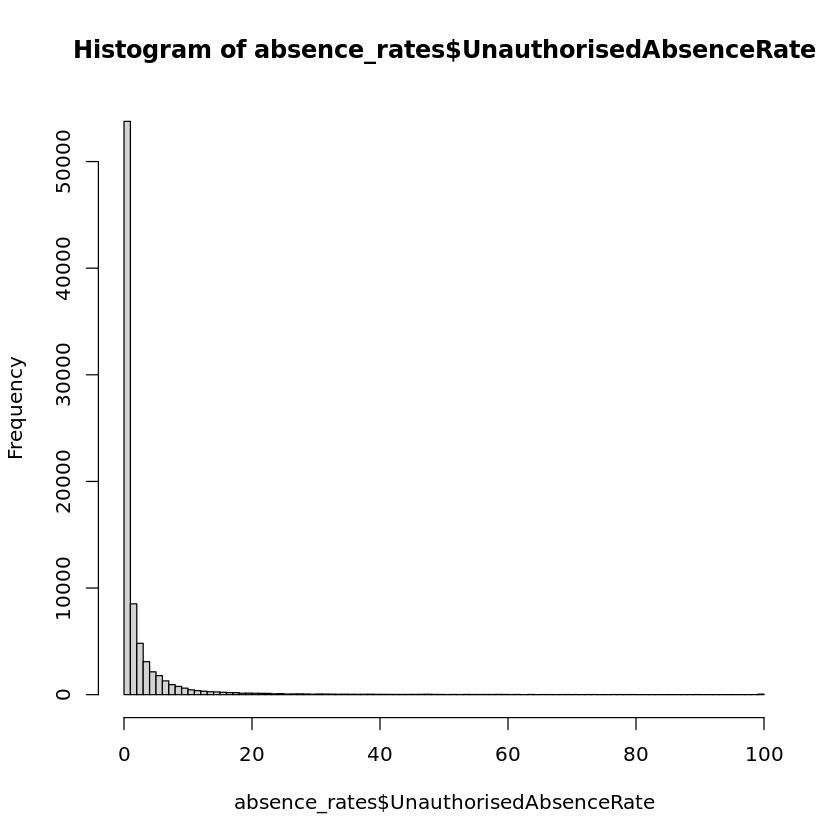

In [258]:
hist(absence_rates$UnauthorisedAbsenceRate, breaks = 100)

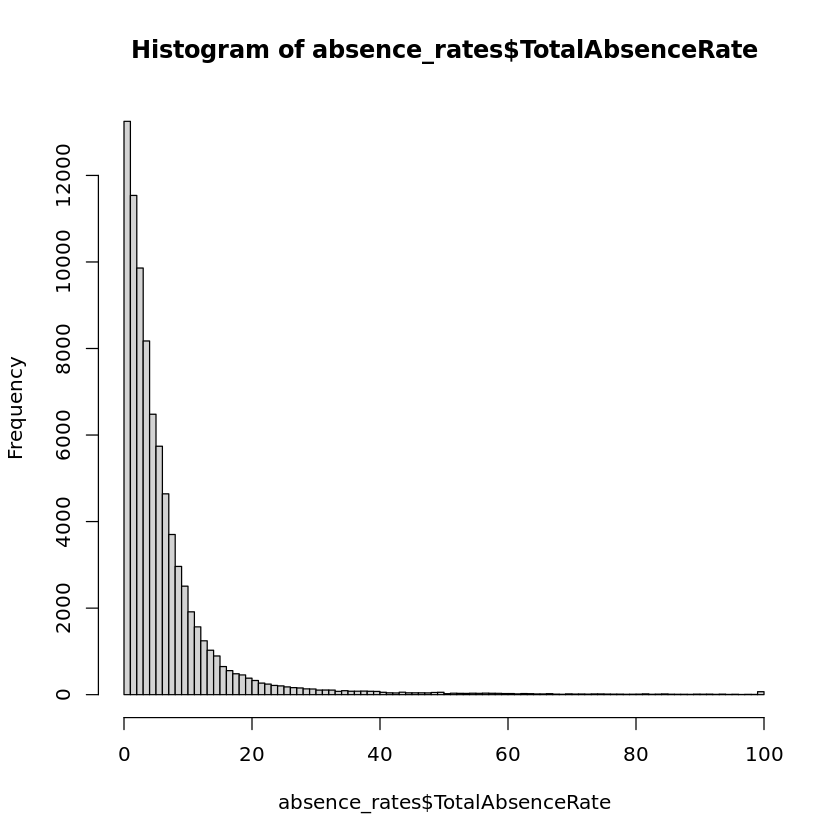

In [259]:
hist(absence_rates$TotalAbsenceRate, breaks = 100)

## Calculate overall rates

In [261]:
head(absence_final)

person_id,AcademicYear,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2012/2013,374,2,0,2
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2013/2014,374,6,0,6
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2014/2015,375,26,0,26
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2016/2017,274,0,0,0
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2012/2013,374,21,0,21
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2013/2014,268,12,2,14


In [262]:
absence_alltime <- absence_final |> 
    group_by(person_id) %>%
      summarise(
        SessionsPossible = sum(SessionsPossible, na.rm = TRUE),
        AuthorisedAbsence = sum(AuthorisedAbsence, na.rm = TRUE),
        UnauthorisedAbsence = sum(UnauthorisedAbsence, na.rm = TRUE),
        OverallAbsence = sum(OverallAbsence, na.rm = TRUE),
        .groups = "drop"
      )

In [264]:
head(absence_alltime)

person_id,SessionsPossible,AuthorisedAbsence,UnauthorisedAbsence,OverallAbsence
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,1637,44,2,46
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,1698,371,26,397
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,1826,54,129,183
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,1663,28,7,35
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,1812,89,0,89
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,1558,57,26,83


In [265]:
absence_alltime_rates <- absence_alltime |>
    mutate(
        AuthorisedAbsenceRate = (AuthorisedAbsence / SessionsPossible)*100,
        UnauthorisedAbsenceRate = (UnauthorisedAbsence / SessionsPossible)*100,
        TotalAbsenceRate = (OverallAbsence / SessionsPossible)*100
    ) |>
    select(-c(SessionsPossible, AuthorisedAbsence, UnauthorisedAbsence, OverallAbsence))

In [266]:
absence_alltime_rates

person_id,AuthorisedAbsenceRate,UnauthorisedAbsenceRate,TotalAbsenceRate
<chr>,<dbl>,<dbl>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2.6878436,0.12217471,2.8100183
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,21.8492344,1.53121319,23.3804476
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2.9572837,7.06462212,10.0219058
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,1.6837041,0.42092604,2.1046302
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,4.9116998,0.00000000,4.9116998
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,3.6585366,1.66880616,5.3273427
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,6.4825254,1.07102593,7.5535513
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,3.2185206,10.44607566,13.6645963
001B7CEB7B4CC529920A0B9F5B83D1AC0019E5DC44B3FBB3CEF665C331C0C3B6,4.8298573,0.98792536,5.8177827


### save as csv

In [267]:
# save as csv
write.csv(absence_alltime_rates, "data/absence_alltime_rates.csv", row.names = FALSE)

## Explore absences

In [268]:
summary(absence_alltime_rates)

  person_id         AuthorisedAbsenceRate UnauthorisedAbsenceRate
 Length:16962       Min.   : 0.000        Min.   :  0.0000       
 Class :character   1st Qu.: 1.610        1st Qu.:  0.1110       
 Mode  :character   Median : 3.025        Median :  0.7029       
                    Mean   : 3.955        Mean   :  2.4654       
                    3rd Qu.: 5.119        3rd Qu.:  2.2685       
                    Max.   :80.688        Max.   :100.0000       
 TotalAbsenceRate 
 Min.   :  0.000  
 1st Qu.:  2.271  
 Median :  4.249  
 Mean   :  6.421  
 3rd Qu.:  7.584  
 Max.   :100.000  

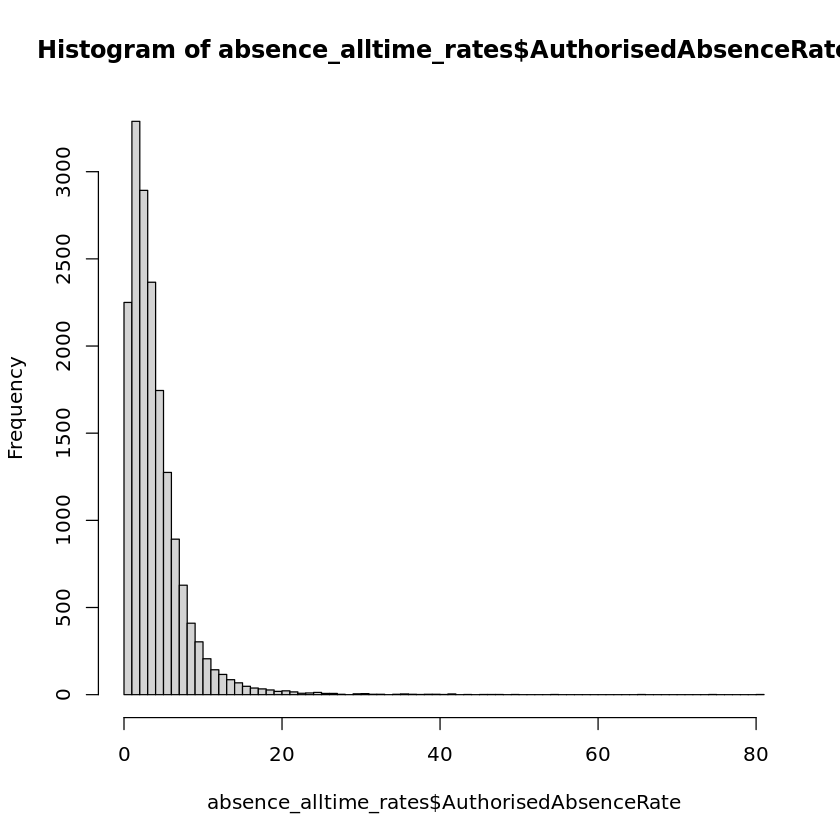

In [269]:
hist(absence_alltime_rates$AuthorisedAbsenceRate, breaks = 100)

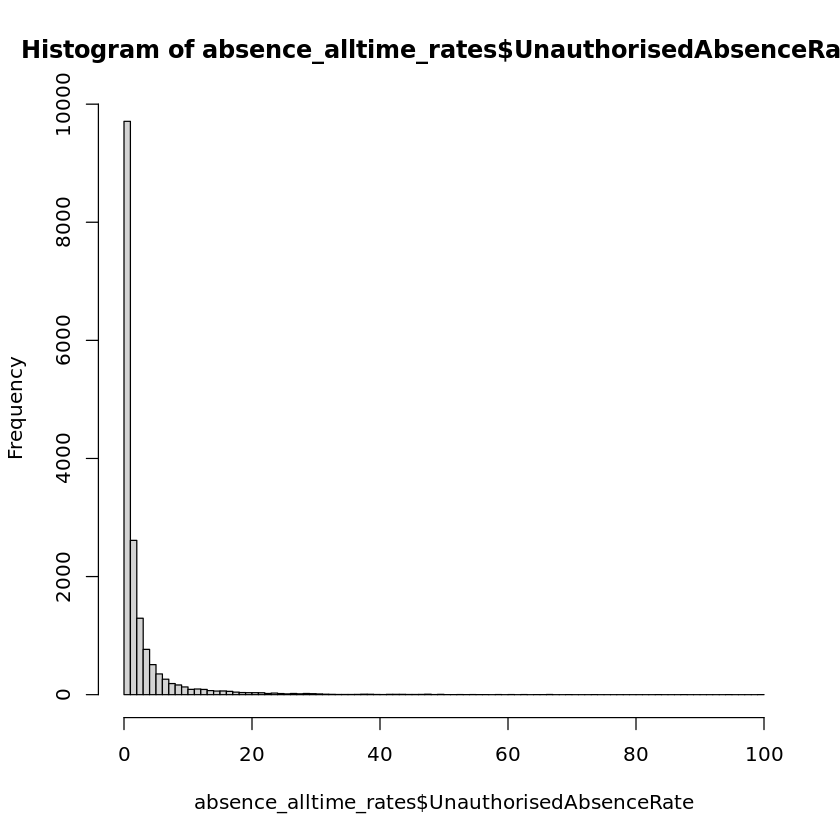

In [270]:
hist(absence_alltime_rates$UnauthorisedAbsenceRate, breaks = 100)

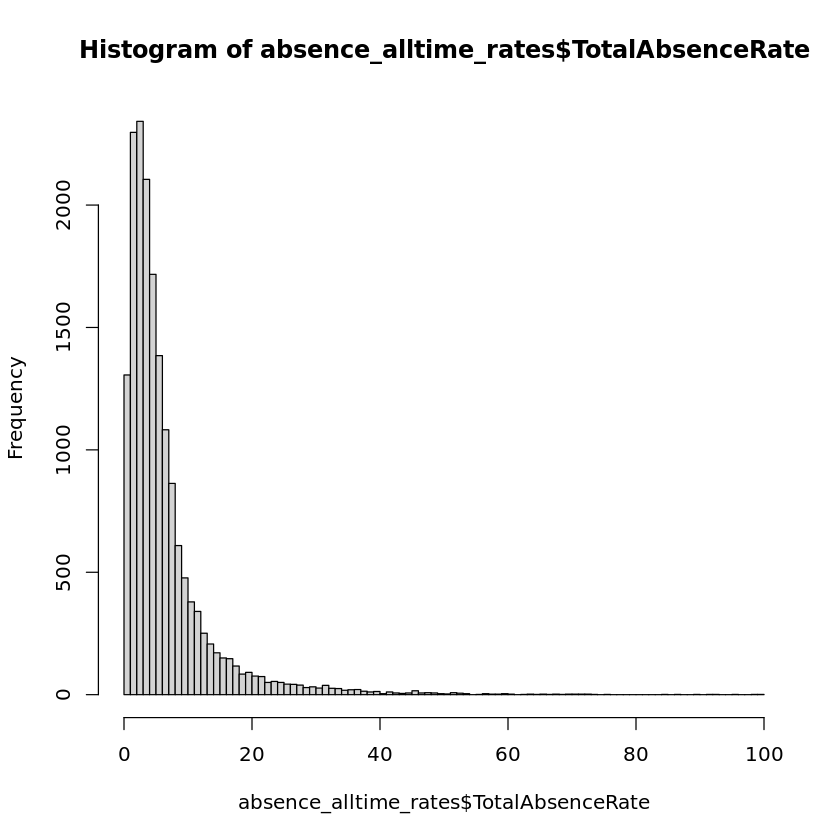

In [271]:
hist(absence_alltime_rates$TotalAbsenceRate, breaks = 100)

# merge with main person data

In [273]:
absence_alltime_rates |>
    summarize(n_distinct(person_id))

n_distinct(person_id)
<int>
16962


In [272]:
data <- read.csv('data/person_home_fsm_sen.csv', header = TRUE)

In [274]:
head(data)

,person_id,ever_SEN_support,first_SEN_support_year,SEN_support_need,ever_EHC_plan,first_EHC_plan_year,EHC_plan_need,no_SEN,birth_date,gender,CombinedEthnicity,cohort,DistCurrSch,DistNearSch,IDACIScore_Home,LSOA11_Home,EAL,ever_fsm
,<chr>,<lgl>,<int>,<chr>,<lgl>,<int>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,TRUE,2016,ASD,FALSE,NA,NA,FALSE,2001-05-15,M,White British,2000/01,0.66,0.66,0.410,E01010635,0,0
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,TRUE,2007,MLD,FALSE,NA,NA,FALSE,2001-01-15,F,White British,2000/01,3.50,0.62,0.397,E01010749,0,0
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,TRUE,2005,"SLCN, MLD",TRUE,2012,MLD,FALSE,2001-11-15,M,White British,2001/02,7.01,0.00,0.125,E01002563,0,1
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,TRUE,2014,MLD,FALSE,NA,NA,FALSE,2002-05-15,M,Other,2001/02,0.57,0.57,0.405,E01010724,1,0
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,FALSE,NA,NA,FALSE,NA,NA,TRUE,2000-11-15,M,South Asian,2000/01,1.69,0.44,0.521,E01010610,1,0
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,TRUE,2017,,FALSE,NA,NA,FALSE,2001-04-15,F,White British,2000/01,1.12,0.62,0.234,E01010815,0,0


In [275]:
join_absence_person <- data |> 
    left_join(absence_alltime_rates, by = join_by(person_id)) 

In [277]:
head(join_absence_person)

,person_id,ever_SEN_support,first_SEN_support_year,SEN_support_need,ever_EHC_plan,first_EHC_plan_year,EHC_plan_need,no_SEN,birth_date,gender,⋯,cohort,DistCurrSch,DistNearSch,IDACIScore_Home,LSOA11_Home,EAL,ever_fsm,AuthorisedAbsenceRate,UnauthorisedAbsenceRate,TotalAbsenceRate
,<chr>,<lgl>,<int>,<chr>,<lgl>,<int>,<chr>,<lgl>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,TRUE,2016,ASD,FALSE,NA,NA,FALSE,2001-05-15,M,⋯,2000/01,0.66,0.66,0.410,E01010635,0,0,2.687844,0.1221747,2.810018
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,TRUE,2007,MLD,FALSE,NA,NA,FALSE,2001-01-15,F,⋯,2000/01,3.50,0.62,0.397,E01010749,0,0,21.849234,1.5312132,23.380448
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,TRUE,2005,"SLCN, MLD",TRUE,2012,MLD,FALSE,2001-11-15,M,⋯,2001/02,7.01,0.00,0.125,E01002563,0,1,2.957284,7.0646221,10.021906
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,TRUE,2014,MLD,FALSE,NA,NA,FALSE,2002-05-15,M,⋯,2001/02,0.57,0.57,0.405,E01010724,1,0,1.683704,0.4209260,2.104630
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,FALSE,NA,NA,FALSE,NA,NA,TRUE,2000-11-15,M,⋯,2000/01,1.69,0.44,0.521,E01010610,1,0,4.911700,0.0000000,4.911700
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,TRUE,2017,,FALSE,NA,NA,FALSE,2001-04-15,F,⋯,2000/01,1.12,0.62,0.234,E01010815,0,0,3.658537,1.6688062,5.327343


### save as csv

In [278]:
# save as csv
write.csv(join_absence_person, "data/person_plus_absence.csv", row.names = FALSE)